# Structural Regularization — Main Figures

Produces publication-style figures for all three structural constraint sweeps:
- **RSA regularization** (notebook 12): penalise attention on solvent-exposed residues
- **SS3-structured regularization** (notebook 13 Section A): penalise attention on coil/loop residues
- **Disorder regularization** (notebook 13 Section B): penalise attention on ordered (low-disorder) residues

Each sweep gets two panels (sequence-level delta and residue-level delta vs shared baseline).
A final comparison section overlays the best λ from each sweep.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing pyproject.toml")


repo_root            = find_repo_root(Path.cwd().resolve())
src_dir              = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

rsa_results_dir              = repo_root / "results" / "rsa_regularization"
ss3_results_dir              = repo_root / "results" / "ss3_regularization"
ss3_high_lambda_results_dir  = repo_root / "results" / "ss3_high_lambda"
disorder_results_dir         = repo_root / "results" / "disorder_regularization"
figures_dir                  = repo_root / "results" / "paper_figures"
figures_dir.mkdir(parents=True, exist_ok=True)


def lambda_dir_name(lambda_value: float) -> str:
    return f"lambda_{int(lambda_value)}" if float(lambda_value).is_integer() else f"lambda_{str(lambda_value).replace('.', 'p')}"


sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

In [2]:
RESIDUE_METRICS = ["test_mcc", "test_auroc", "test_f1", "test_accuracy",
                   "test_precision", "test_recall",
                   "residue_auroc", "residue_auprc", "residue_precision_at_k"]
RESIDUE_CI_METRICS = [
    "Pooling attention AUROC",
    "Pooling attention AUPRC",
    "Pooling attention precision@k",
]


def load_sweep(
    results_dir: Path,
    lambda_col: str = "lambda_rsa",
    baseline_row: "pd.Series | None" = None,
) -> tuple:
    """Return (summary_df, residue_ci_df, loss_df).

    The sweep CSV always has a 'lambda_rsa' column regardless of sweep type;
    it is renamed to lambda_col.  If baseline_row is provided it is used as
    the reference point for delta calculations (used for SS3 and disorder
    sweeps which share the RSA λ=0 checkpoint).
    """
    summary_df = (
        pd.read_csv(results_dir / "sweep_summary.csv")
        .rename(columns={"lambda_rsa": lambda_col})
        .sort_values(lambda_col)
        .reset_index(drop=True)
    )
    summary_df["lambda_label"] = summary_df[lambda_col].map(lambda v: f"{v:g}")
    summary_df["x"]            = np.arange(len(summary_df))

    if baseline_row is None:
        baseline_row = summary_df.loc[summary_df[lambda_col].eq(0.0)].iloc[0]

    for metric in RESIDUE_METRICS:
        summary_df[f"delta_{metric}"] = summary_df[metric] - float(baseline_row[metric])

    residue_ci_rows = []
    for row in summary_df.itertuples(index=False):
        lval = getattr(row, lambda_col)
        with (results_dir / lambda_dir_name(lval) / "metrics.json").open() as fh:
            mp = json.load(fh)
        rs = mp["residue_summary"]
        for metric_label, (mean_k, low_k, high_k, bl_val) in {
            "Pooling attention AUROC":        ("auroc_mean",          "auroc_ci_low",          "auroc_ci_high",          float(baseline_row["residue_auroc"])),
            "Pooling attention AUPRC":        ("auprc_mean",          "auprc_ci_low",          "auprc_ci_high",          float(baseline_row["residue_auprc"])),
            "Pooling attention precision@k": ("precision_at_k_mean", "precision_at_k_ci_low", "precision_at_k_ci_high", float(baseline_row["residue_precision_at_k"])),
        }.items():
            residue_ci_rows.append({
                lambda_col:    lval,
                "x":           row.x,
                "metric":      metric_label,
                "delta_mean":  rs[mean_k] - bl_val,
                "delta_low":   rs[low_k]  - bl_val,
                "delta_high":  rs[high_k] - bl_val,
            })

    loss_rows = []
    for row in summary_df.itertuples(index=False):
        lval = getattr(row, lambda_col)
        with (results_dir / lambda_dir_name(lval) / "metrics.json").open() as fh:
            mp = json.load(fh)
        for split_name, loss_key in [("validation", "validation_loss"), ("test", "test_loss")]:
            cls_loss = float(mp[loss_key]["cls_loss"])
            rsa_loss = mp[loss_key]["rsa_loss"]
            w_rsa    = 0.0 if rsa_loss is None else float(lval) * float(rsa_loss)
            total    = float(mp[loss_key]["total_loss"])
            loss_rows.append({
                lambda_col:               lval,
                "split":                  split_name,
                "classification_loss":    cls_loss,
                "rsa_loss_raw":           np.nan if rsa_loss is None else float(rsa_loss),
                "rsa_loss_weighted":      w_rsa,
                "rsa_fraction_of_total":  w_rsa / total if total else np.nan,
            })

    return summary_df, pd.DataFrame(residue_ci_rows), pd.DataFrame(loss_rows)


def merge_sweeps(
    summary_a: pd.DataFrame, residue_ci_a: pd.DataFrame, loss_a: pd.DataFrame,
    summary_b: pd.DataFrame, residue_ci_b: pd.DataFrame, loss_b: pd.DataFrame,
    lambda_col: str,
) -> tuple:
    """Concatenate two loaded sweeps and re-index x in ascending lambda order."""
    summary = (
        pd.concat([summary_a, summary_b], ignore_index=True)
        .sort_values(lambda_col)
        .reset_index(drop=True)
    )
    summary["x"] = np.arange(len(summary))
    x_map = dict(zip(summary[lambda_col], summary["x"]))

    residue_ci = pd.concat([residue_ci_a, residue_ci_b], ignore_index=True)
    residue_ci["x"] = residue_ci[lambda_col].map(x_map)

    loss = (
        pd.concat([loss_a, loss_b], ignore_index=True)
        .sort_values([lambda_col, "split"])
        .reset_index(drop=True)
    )
    return summary, residue_ci, loss


def prepend_baseline_point(
    summary_df: pd.DataFrame,
    residue_ci_df: pd.DataFrame,
    lambda_col: str,
) -> tuple:
    """Prepend a synthetic λ=0 row (all deltas=0) so every delta plot anchors at the baseline."""
    bl_row = {c: np.nan for c in summary_df.columns}
    bl_row[lambda_col]     = 0.0
    bl_row["lambda_label"] = "0"
    for m in RESIDUE_METRICS:
        bl_row[m]            = float(rsa_baseline[m])
        bl_row[f"delta_{m}"] = 0.0

    new_summary = pd.concat([pd.DataFrame([bl_row]), summary_df], ignore_index=True)
    new_summary["x"] = np.arange(len(new_summary))

    bl_ci_rows = [
        {lambda_col: 0.0, "x": 0, "metric": m,
         "delta_mean": 0.0, "delta_low": 0.0, "delta_high": 0.0}
        for m in RESIDUE_CI_METRICS
    ]
    new_ci    = pd.concat([pd.DataFrame(bl_ci_rows), residue_ci_df], ignore_index=True)
    x_map     = dict(zip(new_summary[lambda_col], new_summary["x"]))
    new_ci["x"] = new_ci[lambda_col].map(x_map)
    return new_summary, new_ci


# RSA sweep has its own λ=0 baseline checkpoint
rsa_summary, rsa_residue_ci, rsa_loss = load_sweep(rsa_results_dir, lambda_col="lambda_rsa")
rsa_baseline = rsa_summary.loc[rsa_summary["lambda_rsa"].eq(0.0)].iloc[0]

# SS3: merge the original sweep (λ=0.1–5, nb 13) with the extended sweep (λ=7–20, nb 15)
ss3_lo_summary, ss3_lo_ci, ss3_lo_loss = load_sweep(
    ss3_results_dir, lambda_col="lambda_ss3", baseline_row=rsa_baseline,
)
ss3_hi_summary, ss3_hi_ci, ss3_hi_loss = load_sweep(
    ss3_high_lambda_results_dir, lambda_col="lambda_ss3", baseline_row=rsa_baseline,
)
ss3_summary, ss3_residue_ci, ss3_loss = merge_sweeps(
    ss3_lo_summary, ss3_lo_ci, ss3_lo_loss,
    ss3_hi_summary, ss3_hi_ci, ss3_hi_loss,
    lambda_col="lambda_ss3",
)

# Disorder sweep shares the RSA λ=0 baseline
disorder_summary, disorder_residue_ci, disorder_loss = load_sweep(
    disorder_results_dir, lambda_col="lambda_disorder", baseline_row=rsa_baseline,
)

# Prepend synthetic λ=0 anchor point to SS3 and disorder delta plots
ss3_summary,      ss3_residue_ci      = prepend_baseline_point(ss3_summary,      ss3_residue_ci,      "lambda_ss3")
disorder_summary, disorder_residue_ci = prepend_baseline_point(disorder_summary, disorder_residue_ci, "lambda_disorder")

print("RSA lambdas:     ", list(rsa_summary["lambda_rsa"]))
print("SS3 lambdas:     ", list(ss3_summary["lambda_ss3"]))
print("Disorder lambdas:", list(disorder_summary["lambda_disorder"]))

RSA lambdas:      [0.0, 0.1, 0.5, 1.0, 5.0]
SS3 lambdas:      [0.0, 0.1, 0.5, 1.0, 5.0, 7.0, 10.0, 15.0, 20.0]
Disorder lambdas: [0.0, 0.1, 0.5, 1.0, 5.0]


In [3]:
def plot_sweep_panels(
    summary_df: pd.DataFrame,
    residue_ci_df: pd.DataFrame,
    xlabel_prefix: str,
    save_stem: str,
) -> tuple:
    """Two-panel figure: sequence-level delta (left) and residue-level delta with CI (right)."""
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2), constrained_layout=True)

    for col, color, label, lw in [
        ("delta_test_mcc",       "#0f766e", "Test MCC",       2.2),
        ("delta_test_auroc",     "#475569", "Test AUROC",     1.8),
        ("delta_test_f1",        "#1d4ed8", "Test F1",        1.8),
        ("delta_test_accuracy",  "#7c3aed", "Test accuracy",  1.8),
        ("delta_test_precision", "#ea580c", "Test precision", 1.6),
        ("delta_test_recall",    "#0891b2", "Test recall",    1.6),
    ]:
        axes[0].plot(summary_df["x"], summary_df[col], marker="o", linewidth=lw, color=color, label=label)
    axes[0].axhline(0, color="#94a3b8", linewidth=1, linestyle="--")
    axes[0].set_xlabel(rf"{xlabel_prefix} regularization strength $\lambda$")
    axes[0].set_ylabel("Delta vs baseline")
    axes[0].set_xticks(summary_df["x"], summary_df["lambda_label"])
    axes[0].legend(frameon=False, loc="upper left", fontsize=8)

    for metric_label, color in [
        ("Pooling attention AUROC",        "#b45309"),
        ("Pooling attention AUPRC",        "#dc2626"),
        ("Pooling attention precision@k", "#334155"),
    ]:
        mdf  = residue_ci_df.loc[residue_ci_df["metric"].eq(metric_label)]
        yerr = np.vstack([mdf["delta_mean"] - mdf["delta_low"], mdf["delta_high"] - mdf["delta_mean"]])
        axes[1].errorbar(
            mdf["x"], mdf["delta_mean"], yerr=yerr,
            marker="o", linewidth=2.0, elinewidth=1.4, capsize=3,
            color=color, ecolor=color, label=metric_label, zorder=3,
        )
    axes[1].axhline(0, color="#94a3b8", linewidth=1, linestyle="--")
    axes[1].set_xlabel(rf"{xlabel_prefix} regularization strength $\lambda$")
    axes[1].set_ylabel("Delta vs baseline (pooling attention)")
    axes[1].set_xticks(summary_df["x"], summary_df["lambda_label"])
    axes[1].legend(frameon=False, loc="upper right", fontsize=8)

    for ax in axes:
        ax.grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
        ax.grid(False, axis="x")

    png = figures_dir / f"{save_stem}.png"
    pdf = figures_dir / f"{save_stem}.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.show()
    return png, pdf

---
## Section A — RSA Regularization

Penalises attention on solvent-exposed residues (high RSA score).  
Baseline: unregularized model (λ = 0) from the same sweep.

In [4]:
rsa_summary[[
    "lambda_rsa", "test_mcc", "test_auroc", "test_f1",
    "test_accuracy", "test_precision", "test_recall",
    "residue_auroc", "residue_auprc", "residue_precision_at_k",
]].round(4)

,lambda_rsa,test_mcc,test_auroc,test_f1,test_accuracy,test_precision,test_recall,residue_auroc,residue_auprc,residue_precision_at_k
0,0.0,0.8336,0.9699,0.9160,0.9165,0.8996,0.9330,0.4677,0.2529,0.2163
1,0.1,0.8293,0.9693,0.9139,0.9143,0.8968,0.9315,0.4679,0.2527,0.2165
2,0.5,0.8474,0.9697,0.9218,0.9237,0.9225,0.9211,0.4660,0.2519,0.2148
3,1.0,0.8390,0.9705,0.9184,0.9194,0.9071,0.9301,0.4667,0.2517,0.2188
4,5.0,0.8460,0.9694,0.9212,0.9230,0.9199,0.9226,0.4570,0.2474,0.2146


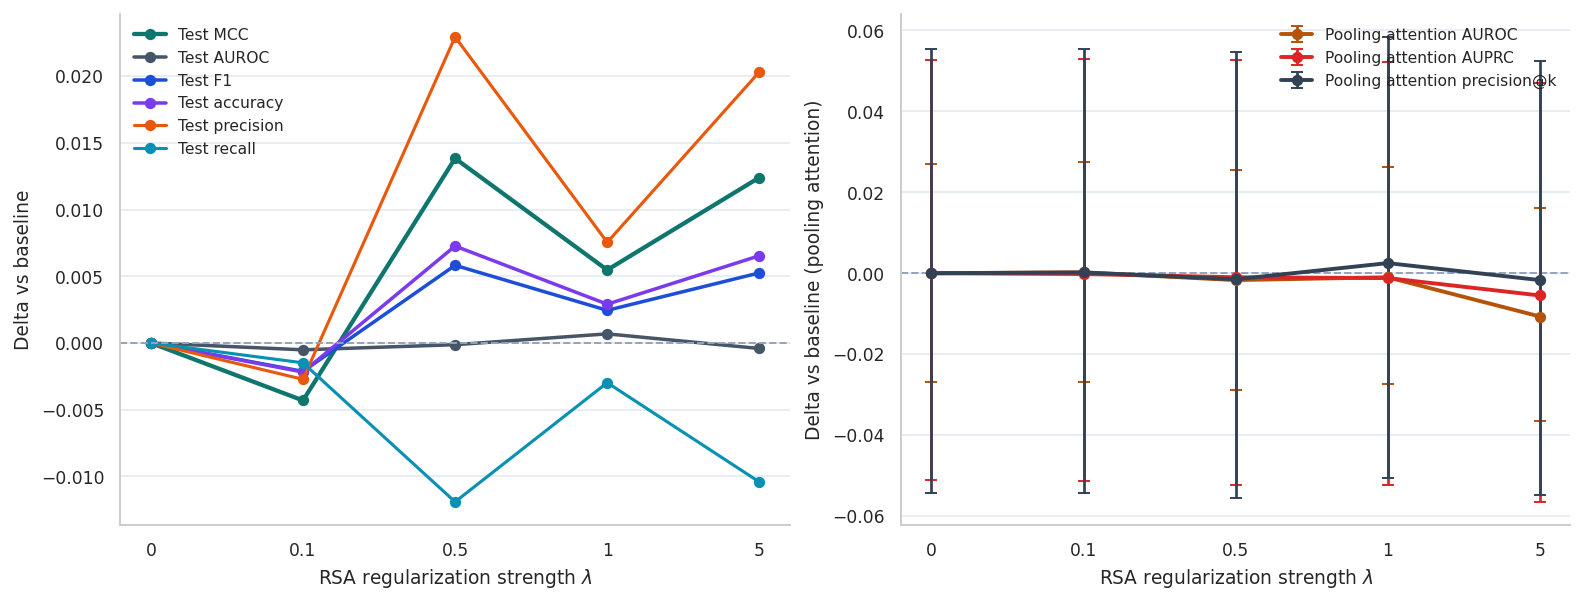

(PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/paper_figures/main_rsa_regularization.png'),
 PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/paper_figures/main_rsa_regularization.pdf'))

In [5]:
plot_sweep_panels(
    rsa_summary, rsa_residue_ci,
    xlabel_prefix="RSA",
    save_stem="main_rsa_regularization",
)

**Caption (RSA):** RSA regularization across λ values 0.1–5.0 leaves sequence-level allergen classification nearly unchanged (left), while pooling-attention epitope residue alignment shows no consistent improvement with overlapping confidence intervals (right). Baseline: unregularized model (λ = 0) from the same sweep.

---
## Section B — SS3-Structured Regularization

Penalises attention on coil/loop residues (secondary-structure class predicted by NetSurfP-3).  
Combines the original sweep (λ ∈ {0.1, 0.5, 1, 5}, notebook 13) with the extended high-λ sweep  
(λ ∈ {7, 10, 15, 20}, notebook 15). Baseline: RSA sweep λ = 0 (shared unregularized checkpoint).

In [6]:
ss3_summary[[
    "lambda_ss3", "test_mcc", "test_auroc", "test_f1",
    "test_accuracy", "test_precision", "test_recall",
    "residue_auroc", "residue_auprc", "residue_precision_at_k",
]].round(4)

,lambda_ss3,test_mcc,test_auroc,test_f1,test_accuracy,test_precision,test_recall,residue_auroc,residue_auprc,residue_precision_at_k
0,0.0,0.8336,0.9699,0.9160,0.9165,0.8996,0.9330,0.4677,0.2529,0.2163
1,0.1,0.8321,0.9690,0.9152,0.9158,0.8994,0.9315,0.4699,0.2537,0.2155
2,0.5,0.8358,0.9698,0.9159,0.9179,0.9165,0.9152,0.4732,0.2553,0.2221
3,1.0,0.8430,0.9697,0.9196,0.9216,0.9196,0.9196,0.4789,0.2583,0.2267
4,5.0,0.8446,0.9684,0.9209,0.9223,0.9148,0.9271,0.5300,0.2863,0.2649
5,7.0,0.8288,0.9677,0.9132,0.9143,0.9026,0.9241,0.5400,0.2909,0.2693
6,10.0,0.8247,0.9646,0.9114,0.9121,0.8975,0.9256,0.5521,0.2988,0.2759
7,15.0,0.8165,0.9643,0.9076,0.9078,0.8876,0.9286,0.5551,0.3002,0.2766
8,20.0,0.7942,0.9616,0.8960,0.8969,0.8818,0.9107,0.5541,0.3005,0.2839


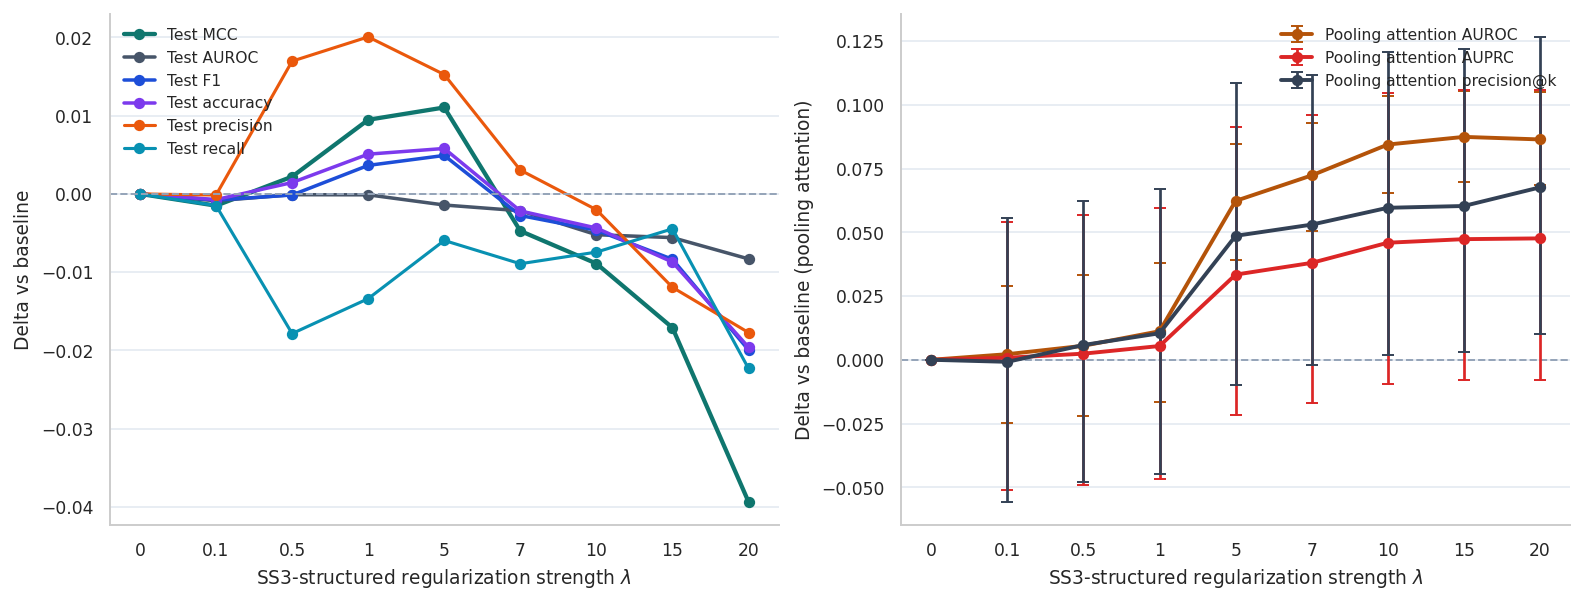

(PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/paper_figures/main_ss3_regularization.png'),
 PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/paper_figures/main_ss3_regularization.pdf'))

In [7]:
plot_sweep_panels(
    ss3_summary, ss3_residue_ci,
    xlabel_prefix="SS3-structured",
    save_stem="main_ss3_regularization",
)

**Caption (SS3-structured):** SS3-structured regularization penalises attention on coil/loop residues across λ values 0.1–20 (original sweep λ ∈ {0.1, 0.5, 1, 5} from notebook 13 combined with extended sweep λ ∈ {7, 10, 15, 20} from notebook 15). Sequence-level classification (left) and pooling-attention residue alignment (right) shown as deltas relative to the shared unregularized baseline (RSA sweep λ = 0).

---
## Section C — Disorder Regularization

Penalises attention on ordered (low-disorder) residues (per-residue disorder score predicted by NetSurfP-3).  
Baseline: RSA sweep λ = 0 (shared unregularized checkpoint).

In [8]:
disorder_summary[[
    "lambda_disorder", "test_mcc", "test_auroc", "test_f1",
    "test_accuracy", "test_precision", "test_recall",
    "residue_auroc", "residue_auprc", "residue_precision_at_k",
]].round(4)

,lambda_disorder,test_mcc,test_auroc,test_f1,test_accuracy,test_precision,test_recall,residue_auroc,residue_auprc,residue_precision_at_k
0,0.0,0.8336,0.9699,0.9160,0.9165,0.8996,0.9330,0.4677,0.2529,0.2163
1,0.1,0.8365,0.9697,0.9175,0.9179,0.9010,0.9345,0.4689,0.2534,0.2159
2,0.5,0.8306,0.9696,0.9144,0.9150,0.8993,0.9301,0.4680,0.2529,0.2162
3,1.0,0.8365,0.9698,0.9175,0.9179,0.9010,0.9345,0.4653,0.2515,0.2168
4,5.0,0.8267,0.9692,0.9128,0.9129,0.8920,0.9345,0.4523,0.2448,0.2112


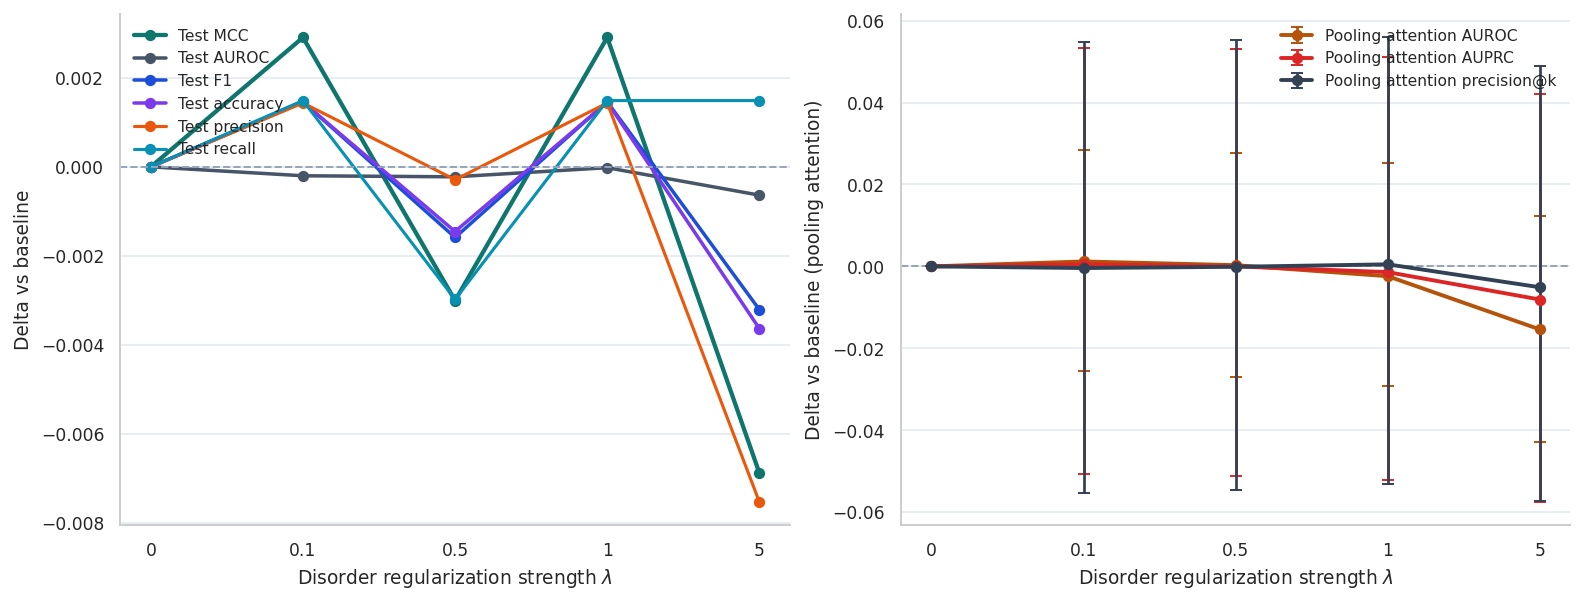

(PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/paper_figures/main_disorder_regularization.png'),
 PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/paper_figures/main_disorder_regularization.pdf'))

In [9]:
plot_sweep_panels(
    disorder_summary, disorder_residue_ci,
    xlabel_prefix="Disorder",
    save_stem="main_disorder_regularization",
)

**Caption (Disorder):** Disorder regularization penalises attention on ordered residues across λ values 0.1–5.0. Sequence-level classification (left) and pooling-attention residue alignment (right) shown as deltas relative to the shared unregularized baseline (RSA sweep λ = 0).

---
## Section D — Cross-Sweep Comparison

Best λ per sweep (selected by validation MCC) compared against the shared unregularized baseline.

In [10]:
DISPLAY_COLS = [
    "sweep", "best_lambda",
    "val_mcc", "test_mcc", "test_auroc", "test_f1", "test_accuracy",
    "residue_auroc", "residue_auprc", "residue_precision_at_k",
]


def pick_best(summary_df: pd.DataFrame, lambda_col: str, sweep_name: str) -> dict:
    row = summary_df.loc[summary_df["val_mcc"].idxmax()]
    return {
        "sweep":       sweep_name,
        "best_lambda": float(row[lambda_col]),
        **{c: float(row[c]) for c in DISPLAY_COLS if c not in ("sweep", "best_lambda") and c in row.index},
    }


baseline_entry = {
    "sweep":       "Baseline (λ=0)",
    "best_lambda": 0.0,
    **{c: float(rsa_baseline[c]) for c in DISPLAY_COLS if c not in ("sweep", "best_lambda") and c in rsa_baseline.index},
}

comparison_df = pd.DataFrame([
    baseline_entry,
    pick_best(rsa_summary.loc[rsa_summary["lambda_rsa"].ne(0.0)], "lambda_rsa",    "RSA"),
    pick_best(ss3_summary,                                          "lambda_ss3",    "SS3-structured"),
    pick_best(disorder_summary,                                     "lambda_disorder", "Disorder"),
], columns=DISPLAY_COLS).round(4)

comparison_df

,sweep,best_lambda,val_mcc,test_mcc,test_auroc,test_f1,test_accuracy,residue_auroc,residue_auprc,residue_precision_at_k
0,Baseline (λ=0),0.0,0.8454,0.8336,0.9699,0.9160,0.9165,0.4677,0.2529,0.2163
1,RSA,0.5,0.8597,0.8474,0.9697,0.9218,0.9237,0.4660,0.2519,0.2148
2,SS3-structured,5.0,0.8777,0.8446,0.9684,0.9209,0.9223,0.5300,0.2863,0.2649
3,Disorder,5.0,0.8525,0.8267,0.9692,0.9128,0.9129,0.4523,0.2448,0.2112


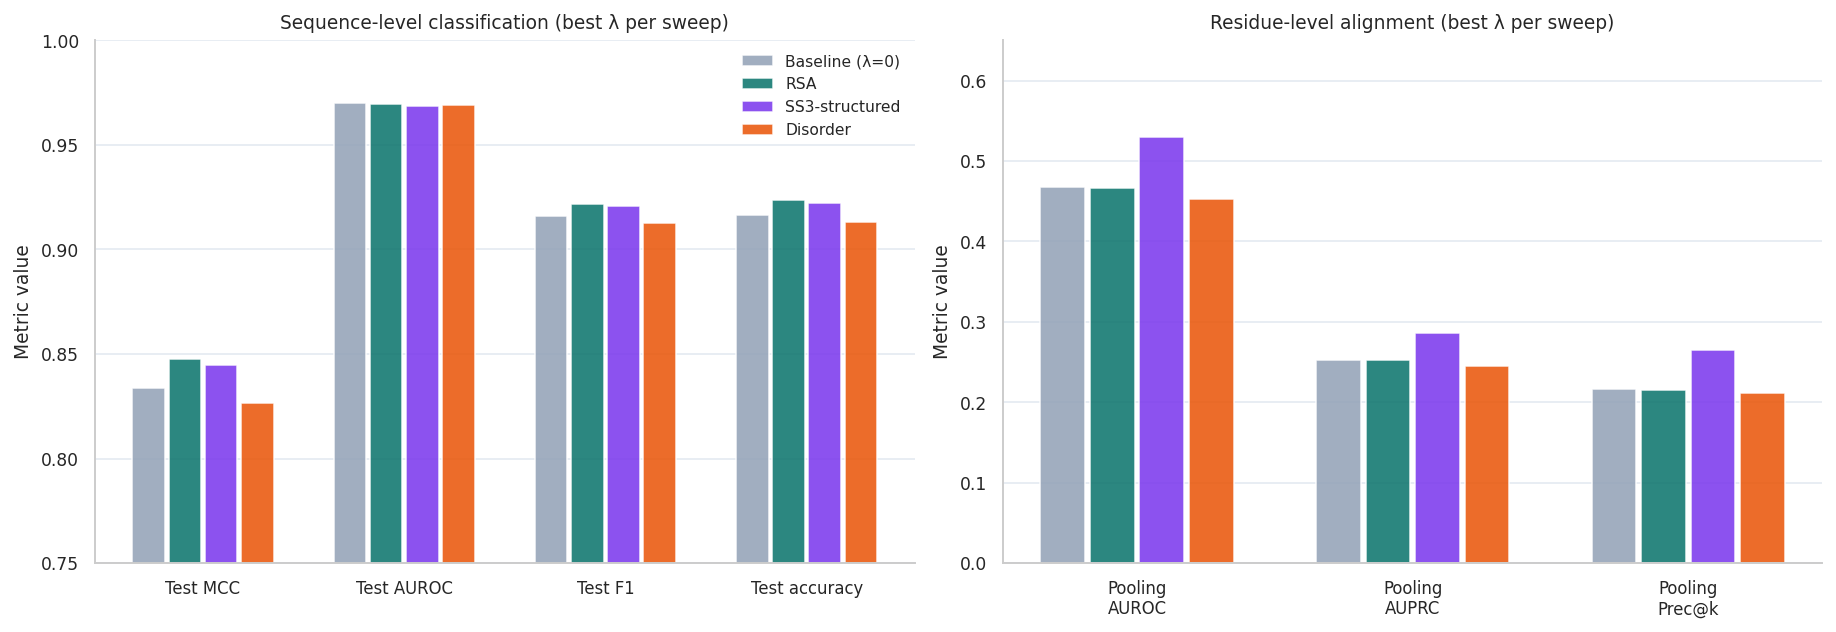

(PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/paper_figures/main_structural_regularization_comparison.png'),
 PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/paper_figures/main_structural_regularization_comparison.pdf'))

In [11]:
SWEEP_COLORS = {
    "Baseline (λ=0)":  "#94a3b8",
    "RSA":             "#0f766e",
    "SS3-structured":  "#7c3aed",
    "Disorder":        "#ea580c",
}
SWEEPS = list(SWEEP_COLORS)

SEQ_METRICS = [("test_mcc", "Test MCC"), ("test_auroc", "Test AUROC"),
               ("test_f1", "Test F1"),   ("test_accuracy", "Test accuracy")]
RES_METRICS = [("residue_auroc", "Pooling\nAUROC"),
               ("residue_auprc", "Pooling\nAUPRC"),
               ("residue_precision_at_k", "Pooling\nPrec@k")]

x_seq  = np.arange(len(SEQ_METRICS))
x_res  = np.arange(len(RES_METRICS))
width  = 0.18

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), constrained_layout=True)

for i, sweep_name in enumerate(SWEEPS):
    row    = comparison_df.loc[comparison_df["sweep"].eq(sweep_name)].iloc[0]
    color  = SWEEP_COLORS[sweep_name]
    offset = (i - 1.5) * width
    axes[0].bar(x_seq + offset, [float(row[c]) for c, _ in SEQ_METRICS],
                width=width * 0.9, color=color, label=sweep_name, alpha=0.88)
    axes[1].bar(x_res + offset, [float(row[c]) for c, _ in RES_METRICS],
                width=width * 0.9, color=color, alpha=0.88)

axes[0].set_xticks(x_seq, [label for _, label in SEQ_METRICS])
axes[0].set_ylabel("Metric value")
axes[0].set_title("Sequence-level classification (best λ per sweep)")
axes[0].legend(frameon=False, fontsize=8)
axes[0].set_ylim(0.75, 1.0)

axes[1].set_xticks(x_res, [label for _, label in RES_METRICS])
axes[1].set_ylabel("Metric value")
axes[1].set_title("Residue-level alignment (best λ per sweep)")
axes[1].set_ylim(0.0, 0.65)

for ax in axes:
    ax.grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
    ax.grid(False, axis="x")
    ax.tick_params(axis="x", labelsize=8.5)

cmp_png = figures_dir / "main_structural_regularization_comparison.png"
cmp_pdf = figures_dir / "main_structural_regularization_comparison.pdf"
fig.savefig(cmp_png, bbox_inches="tight")
fig.savefig(cmp_pdf, bbox_inches="tight")
plt.show()
cmp_png, cmp_pdf

**Caption (comparison):** Best-λ comparison of all three structural regularization strategies against the unregularized baseline. Sequence-level classification (left) is stable across conditions; residue-level pooling-attention alignment (right) shows modest variation but no consistent gain over baseline.

---
## Section E — Loss Decomposition

Weighted structural-penalty share of total test loss across λ for each sweep.  
Shows that the classification loss dominates throughout.

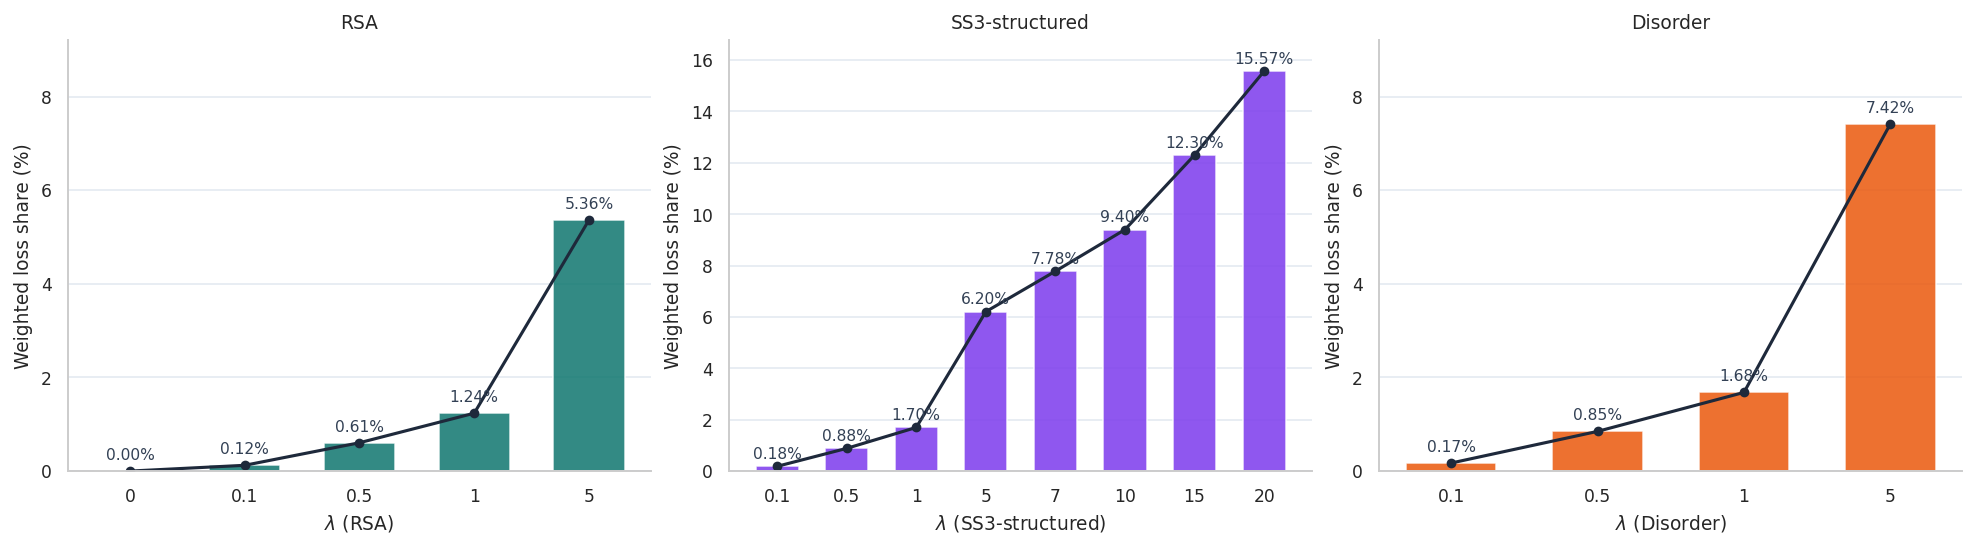

(PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/paper_figures/main_structural_regularization_loss_decomposition.png'),
 PosixPath('/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/paper_figures/main_structural_regularization_loss_decomposition.pdf'))

In [12]:
def test_loss_pct(loss_df: pd.DataFrame, summary_df: pd.DataFrame, lambda_col: str) -> pd.DataFrame:
    df = (
        loss_df.loc[loss_df["split"].eq("test")]
        .sort_values(lambda_col)
        .reset_index(drop=True)
        .merge(summary_df[[lambda_col, "x"]], on=lambda_col, how="left")
    )
    df["rsa_fraction_pct"] = 100.0 * df["rsa_fraction_of_total"]
    return df


# RSA: include λ=0 (shows 0 % penalty share) as the leftmost bar
rsa_tl      = test_loss_pct(rsa_loss,      rsa_summary,      "lambda_rsa")
ss3_tl      = test_loss_pct(ss3_loss,      ss3_summary,      "lambda_ss3")
disorder_tl = test_loss_pct(disorder_loss, disorder_summary, "lambda_disorder")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

for ax, tl_df, lambda_col, title, color in [
    (axes[0], rsa_tl,      "lambda_rsa",      "RSA",            "#0f766e"),
    (axes[1], ss3_tl,      "lambda_ss3",      "SS3-structured", "#7c3aed"),
    (axes[2], disorder_tl, "lambda_disorder", "Disorder",       "#ea580c"),
]:
    ax.bar(tl_df["x"], tl_df["rsa_fraction_pct"], color=color, width=0.62, alpha=0.85)
    ax.plot(tl_df["x"], tl_df["rsa_fraction_pct"], color="#1e293b", linewidth=1.6, marker="o", markersize=4)
    ax.set_xlabel(rf"$\lambda$ ({title})")
    ax.set_ylabel(r"Weighted loss share (%)")
    ax.set_title(title)
    ax.set_xticks(tl_df["x"], tl_df[lambda_col].map(lambda v: f"{v:g}"))
    ax.grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
    ax.grid(False, axis="x")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for xv, pct in zip(tl_df["x"], tl_df["rsa_fraction_pct"]):
        ax.text(xv, pct + 0.18, f"{pct:.2f}%", ha="center", va="bottom", fontsize=8, color="#334155")
    ax.set_ylim(0, max(8.0, float(tl_df["rsa_fraction_pct"].max())) + 1.2)

loss_png = figures_dir / "main_structural_regularization_loss_decomposition.png"
loss_pdf = figures_dir / "main_structural_regularization_loss_decomposition.pdf"
fig.savefig(loss_png, bbox_inches="tight")
fig.savefig(loss_pdf, bbox_inches="tight")
plt.show()
loss_png, loss_pdf

**Caption (loss decomposition):** Weighted structural-penalty share of total test loss for each sweep. The classification loss dominates throughout all three regularization strategies, confirming that the structural penalty functions as a soft regularizer that does not override the primary training signal.